# Fichier de débug pour trouver le composant problématique - mesure d'angle

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils.legacy import calculate_angle, correlation
from scipy.io import wavfile
from dataclasses import dataclass,field
from scipy import signal
%matplotlib widget

# Parameters:

TARGET_FREQS_HZ = (8800.0, 37500.0)
TARGET_BANDWIDTH_HZ = 1000.0
FILTER_ORDER = 4
WIENER_WINDOW = 31
DISTANCE_HYDROPHONES = 0.62
CELERITY = 1500
NUM_BLOCKS_FOR_ANGLE_CALCULATION = 47
ANGLE_BLOCK_SIZE = 4096 # 21ms par petit bloc

## 0 - Importation d'un fichier audio enregistré en tableau Numpy

In [2]:
# Choix du fichier utilisé
file_path = "input/30_gauche.wav"

In [3]:
SAMPLE_RATE,audio_data = wavfile.read(file_path) # audio_data.shape = (num_échantillons,2) pour les deux pistes audio
audio_data=audio_data/2**31   
len_samples = len(audio_data)                    # Nombre d'échantillons dans l'enregistrement
len_time = len_samples/SAMPLE_RATE               # Normalisation pour un fichier avec des entiers en 32 bits

In [4]:
def plot_signals_time(audio:np.ndarray,sample_rate:int = SAMPLE_RATE):
    """Fonction pour afficher signal au cours du temps. Ce signal peut être 1D ou 2D (shape(n_samples,2))"""
    time = np.linspace(0,len(audio)/sample_rate,len(audio))
    plt.plot(time,audio,alpha=0.7)
    plt.show()
    plt.close()

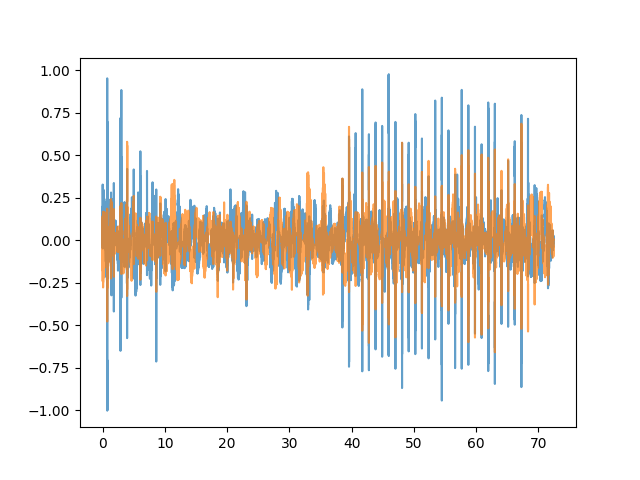

In [5]:
plot_signals_time(audio_data,SAMPLE_RATE)

## 1 - Filtrage du signal brut

In [6]:
@dataclass
class MultiBandDoubleWienerProcessor:
    """Realtime processor: multi-band band-pass + two Wiener passes."""

    sample_rate: float
    target_freqs: tuple[float, ...]
    bandwidth_hz: float
    order: int = FILTER_ORDER
    wiener_window: int = WIENER_WINDOW
    _sos_filters: list[np.ndarray] = field(init=False, default_factory=list, repr=False)
    _channel_zi: list[list[np.ndarray]] = field(init=False, default_factory=list, repr=False)

    def __post_init__(self) -> None:
        if self.sample_rate <= 0:
            raise ValueError("sample_rate must be positive.")
        if not self.target_freqs:
            raise ValueError("target_freqs must contain at least one frequency.")
        if self.bandwidth_hz <= 0:
            raise ValueError("bandwidth_hz must be positive.")
        if self.order <= 0:
            raise ValueError("order must be a positive integer.")

        nyquist = self.sample_rate / 2.0
        half_band = self.bandwidth_hz / 2.0
        self._sos_filters = []
        for target_freq in self.target_freqs:
            if target_freq <= 0:
                raise ValueError("All target frequencies must be positive.")
            lowcut = float(target_freq) - half_band
            highcut = float(target_freq) + half_band
            if lowcut <= 0 or highcut >= nyquist:
                raise ValueError(
                    "Invalid band: each target +/- bandwidth_hz/2 must stay within (0, Nyquist)."
                )
            sos = signal.butter(
                self.order,
                [lowcut, highcut],
                btype="bandpass",
                fs=self.sample_rate,
                output="sos",
            ).astype(np.float32)
            self._sos_filters.append(sos)

    def reset(self) -> None:
        self._channel_zi = []

    def _ensure_channel_state(self, channels: int) -> None:
        if channels <= 0:
            raise ValueError("channels must be positive.")
        if len(self._channel_zi) == channels:
            return
        self._channel_zi = []
        for _ in range(channels):
            channel_states = []
            for sos in self._sos_filters:
                channel_states.append(signal.sosfilt_zi(sos).astype(np.float32))
            self._channel_zi.append(channel_states)

    def process(self, data: np.ndarray) -> np.ndarray:
        block = np.asarray(data, dtype=np.float32)
        if block.ndim != 2:
            raise ValueError("process expects shape (samples, channels).")
        if block.size == 0:
            return block.copy()

        self._ensure_channel_state(block.shape[1])
        filtered = np.empty_like(block, dtype=np.float32)
        win_size = min(int(self.wiener_window), block.shape[0])
        if win_size % 2 == 0:
            win_size = max(1, win_size - 1)

        for ch_idx in range(block.shape[1]):
            combined_band = np.zeros(block.shape[0], dtype=np.float32)
            for band_idx, sos in enumerate(self._sos_filters):
                bandpassed, self._channel_zi[ch_idx][band_idx] = signal.sosfilt(
                    sos, block[:, ch_idx], zi=self._channel_zi[ch_idx][band_idx]
                )
                combined_band += bandpassed.astype(np.float32, copy=False)
            first_pass = signal.wiener(combined_band, mysize=win_size)
            second_pass = signal.wiener(first_pass, mysize=win_size)
            filtered[:, ch_idx] = second_pass.astype(np.float32, copy=False)
        return filtered

In [7]:
filter_processor = MultiBandDoubleWienerProcessor(
            sample_rate=SAMPLE_RATE,
            target_freqs=TARGET_FREQS_HZ,
            bandwidth_hz=TARGET_BANDWIDTH_HZ,
            order=FILTER_ORDER,
            wiener_window=WIENER_WINDOW,
        )

In [8]:
processed_audio = filter_processor.process(audio_data)

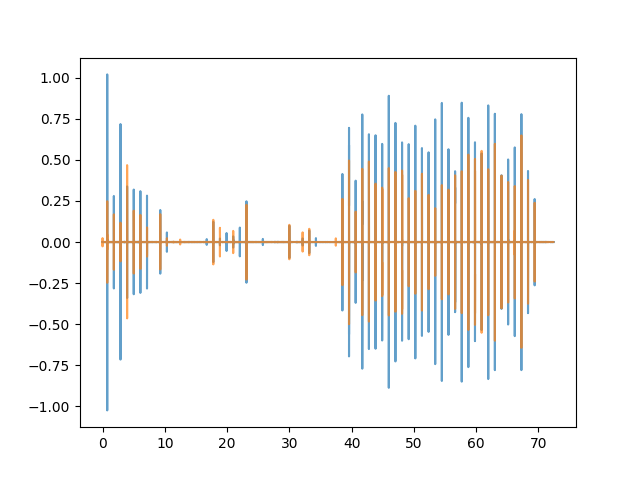

In [9]:
plot_signals_time(processed_audio)

## 2 - Séparer l'enregistrement en sous échantillons plus courts de 1s

In [10]:
len_onesec_block = ANGLE_BLOCK_SIZE*NUM_BLOCKS_FOR_ANGLE_CALCULATION # Bloc de 192512 échantillons/1.002s
def split_in_onesec_audios(audio : np.ndarray):
    audio_copy = audio.copy()
    num_onesec_block = len(audio_copy)//len_onesec_block
    audio_copy = audio_copy[:num_onesec_block*len_onesec_block]
    blocks = audio_copy.reshape(num_onesec_block,-1,2)
    return blocks

In [11]:
raw_blocks = split_in_onesec_audios(audio_data)
processed_blocks = split_in_onesec_audios(processed_audio)

In [80]:
num_onessec_blocks = raw_blocks.shape[0]
index_block_sampled = 3*num_onessec_blocks//4+10

In [81]:
raw_block = raw_blocks[index_block_sampled]
processed_block = processed_blocks[index_block_sampled]

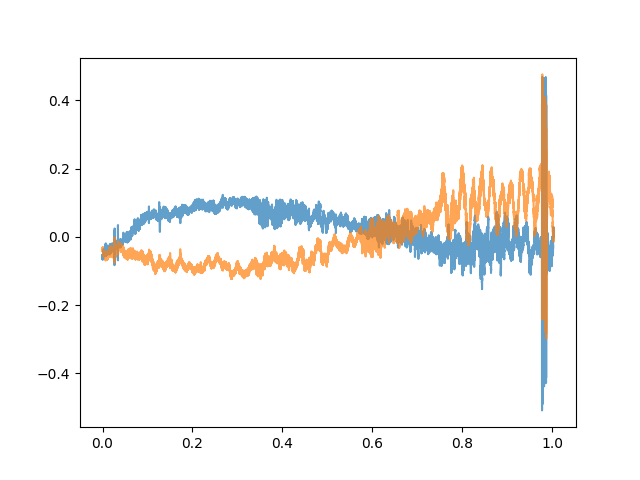

In [82]:
plot_signals_time(raw_block)

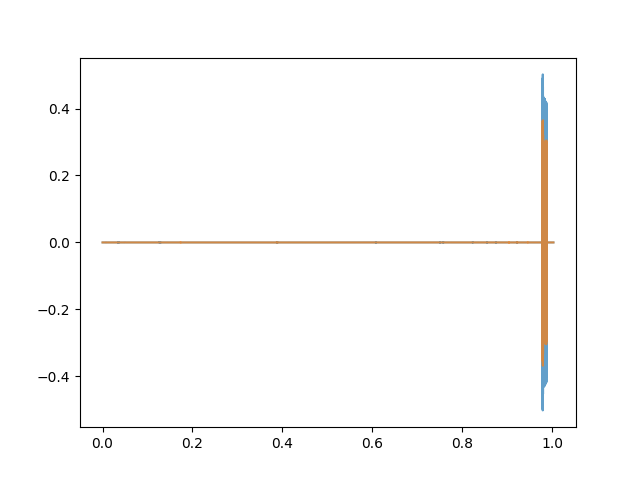

In [83]:
plot_signals_time(processed_block)

## 3 - Séparer l'enregistrement court en sous blocs de 21ms

In [84]:
def split_in_short_audios(block : np.ndarray):
    block_copy = block.copy()
    small_blocks = block_copy.reshape(-1,ANGLE_BLOCK_SIZE,2)
    return small_blocks

In [85]:
short_raw_blocks = split_in_short_audios(raw_block)
short_processed_blocks = split_in_short_audios(processed_block)

In [86]:
short_raw_blocks.shape

(47, 4096, 2)

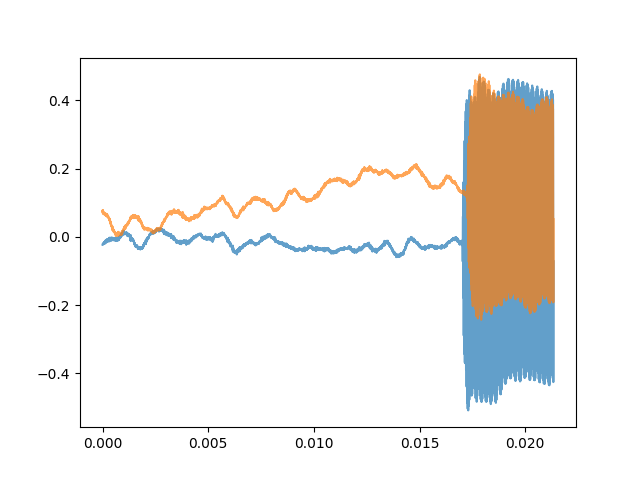

In [90]:
plot_signals_time(short_raw_blocks[45])

## 4- Detecteur du signal contenant le bip

In [93]:
def detecteur_signal(short_blocks):
    ch1 = short_blocks[:, :, 0]
    norm_ch1 = np.linalg.norm(ch1, axis=1)
    highest_index = np.argmax(norm_ch1)
    print(highest_index)
    if highest_index == 0:
        stereo_window = short_processed_blocks[highest_index:highest_index+2].reshape(-1,2)
    elif highest_index == len(ch1)-1:
        stereo_window = short_processed_blocks[highest_index - 1:highest_index + 1].reshape(-1,2)
    else:
        stereo_window = short_processed_blocks[highest_index - 1:highest_index + 2].reshape(-1,2)
    return stereo_window

In [94]:
interest_window = detecteur_signal(short_processed_blocks)

46


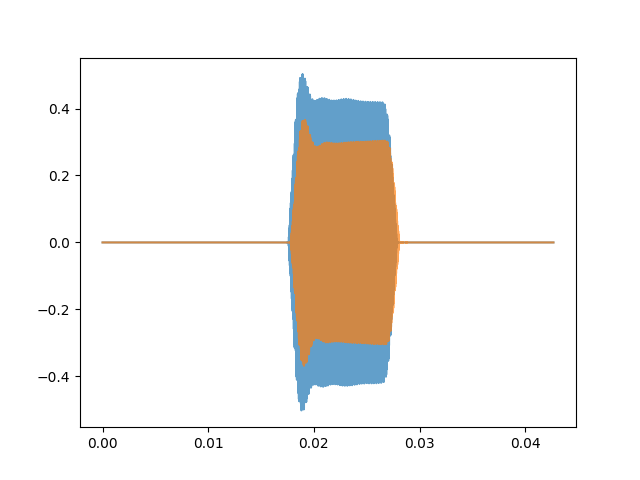

In [95]:
plot_signals_time(interest_window)

In [109]:
max_index = np.argmax(interest_window[:,0])
print(max_index)

3636


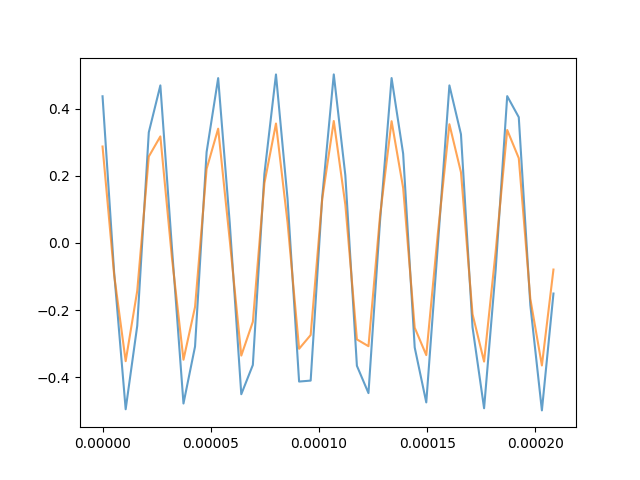

In [110]:
plot_signals_time(interest_window[max_index-20:max_index+20,:])

## 5 - Calcul du décalage entre les signaux

In [ ]:
delay = correlation(interest_window[:,0], interest_window[:,1])
print(delay)

-47


In [115]:
ch1 = interest_window[:,0]
ch2_slide = np.roll(interest_window[:,1],delay)

In [116]:
stereo_slide = np.column_stack([ch1,ch2_slide])

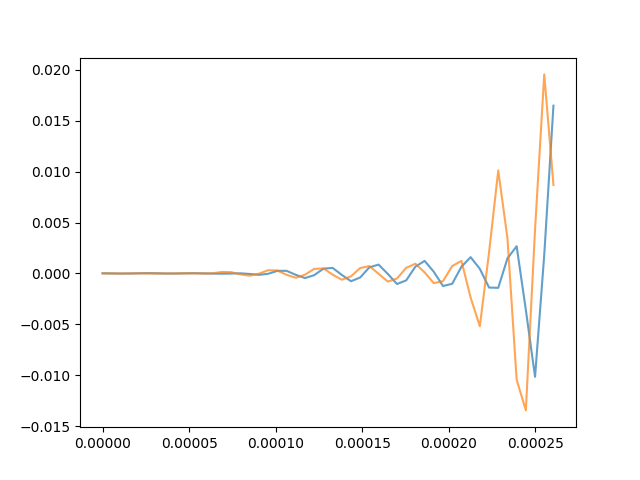

In [117]:
plot_signals_time(stereo_slide[max_index-300:max_index-250,:])

## 6 - Mesure d'angle

In [119]:
angle = calculate_angle(delay,sample_rate=SAMPLE_RATE,distance_microphones=DISTANCE_HYDROPHONES,celerity=CELERITY)

Delay measured between the two signals: -0.00024479166666666665
Number of samples between the two signals: -47


In [120]:
print(angle)

-36.3159779481307
